<a href="https://colab.research.google.com/github/adithyaashok10/AI-ML-Intership/blob/main/Image_Preprocessing_day_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

path = kagglehub.dataset_download("anthonytherrien/dog-vs-cat")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dog-vs-cat' dataset.
Path to dataset files: /kaggle/input/dog-vs-cat


In [ ]:
import os
import cv2

In [ ]:
import matplotlib.pyplot as plt

image_files = []
for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            image_files.append(os.path.join(root, file))

print(f"Found {len(image_files)} image files.")

Found 1000 image files.


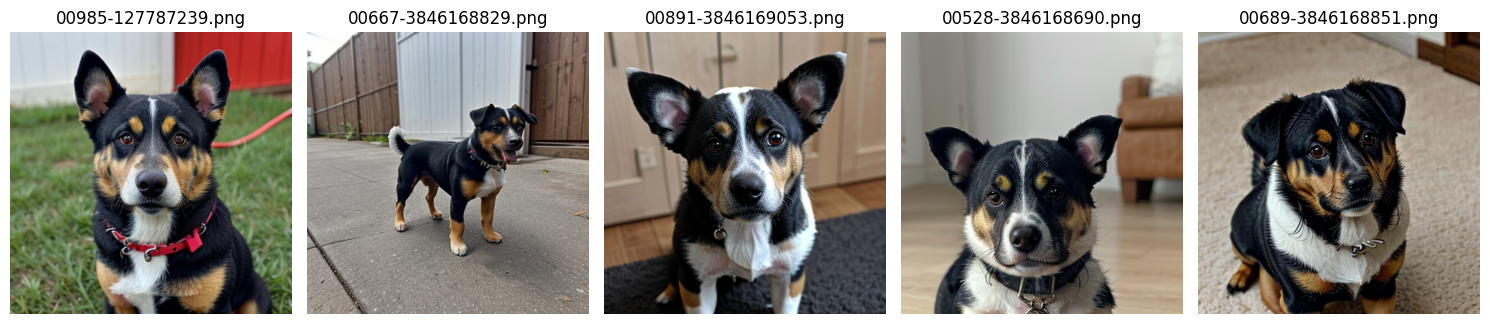

In [ ]:
num_images_to_display = min(5, len(image_files))

plt.figure(figsize=(15, 5))
for i in range(num_images_to_display):
    image_path = image_files[i]
    image = cv2.imread(image_path)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1, num_images_to_display, i + 1)
    plt.imshow(image_rgb)
    plt.title(os.path.basename(image_path))
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

image_data = []
for image_path in image_files:
    image = cv2.imread(image_path)
    if image is not None:
        height, width, channels = image.shape
        image_data.append({
            'filename': os.path.basename(image_path),
            'height': height,
            'width': width,
            'channels': channels
        })

image_df = pd.DataFrame(image_data)
display(image_df.head())

,filename,height,width,channels
0,00985-127787239.png,512,512,3
1,00667-3846168829.png,512,512,3
2,00891-3846169053.png,512,512,3
3,00528-3846168690.png,512,512,3
4,00689-3846168851.png,512,512,3


In [ ]:
resized_images = []
target_size = (224, 224)

print(f"Resizing {len(image_files)} images to {target_size}...")

for image_path in image_files:
    image = cv2.imread(image_path)
    if image is not None:
        resized_image = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)
        resized_images.append(resized_image)
    else:
        print(f"Warning: Could not read image {image_path}")

print(f"Successfully resized {len(resized_images)} images.")

if resized_images:
    print(f"Example resized image shape: {resized_images[0].shape}")

Resizing 1000 images to (224, 224)...
Successfully resized 1000 images.
Example resized image shape: (224, 224, 3)


In [ ]:
grayscale_images = []
rgb_images = []
hsv_images = []

for img in resized_images:
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    grayscale_images.append(gray_img)

    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    rgb_images.append(rgb_img)

    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hsv_images.append(hsv_img)

print(f"Converted {len(grayscale_images)} images to Grayscale.")
print(f"Converted {len(rgb_images)} images to RGB.")
print(f"Converted {len(hsv_images)} images to HSV.")

if grayscale_images:
    print(f"Example Grayscale image shape: {grayscale_images[0].shape}")
if rgb_images:
    print(f"Example RGB image shape: {rgb_images[0].shape}")
if hsv_images:
    print(f"Example HSV image shape: {hsv_images[0].shape}")

Converted 1000 images to Grayscale.
Converted 1000 images to RGB.
Converted 1000 images to HSV.
Example Grayscale image shape: (224, 224)
Example RGB image shape: (224, 224, 3)
Example HSV image shape: (224, 224, 3)


In [ ]:
normalized_images = []

for img_rgb in rgb_images:
    normalized_img = img_rgb.astype('float32') / 255.0
    normalized_images.append(normalized_img)

print(f"Normalized {len(normalized_images)} RGB images.")

if normalized_images:
    print(f"Example normalized image shape: {normalized_images[0].shape}")
    print(f"Example normalized image min value: {normalized_images[0].min()}")
    print(f"Example normalized image max value: {normalized_images[0].max()}")

Normalized 1000 RGB images.
Example normalized image shape: (224, 224, 3)
Example normalized image min value: 0.0
Example normalized image max value: 0.9882352948188782


In [ ]:
!pip install imgaug --quiet

In [ ]:
from PIL import Image, ImageEnhance, ImageOps
import os

# Create a directory for augmented images
augmented_dir = "augmented_images"
#Creates the directory augmented_images
os.makedirs(augmented_dir, exist_ok=True)
 #Ensures no error is raised if the directory already exists.

# Augmentation functions
def augment_image(image_pil, output_dir):
    # 1. Horizontal Flip
    # Flips the image horizontally (mirroring).
    flipped = ImageOps.mirror(image_pil)
    #Saves the flipped image as flipped.jpeg in the output_dir
    flipped.save(os.path.join(output_dir, "flipped.jpeg"))

    # 2. Rotate
    rotated = image_pil.rotate(30)
    #Rotates the image by 30 degrees (counterclockwise by default)
    rotated.save(os.path.join(output_dir, "rotated.jpeg"))

    # 3. Brightness Adjustment
    enhancer = ImageEnhance.Brightness(image_pil)
    #Adjusts brightness by a factor of 1.5 (1.0 = original brightness).
    brighter = enhancer.enhance(1.5)
    brighter.save(os.path.join(output_dir, "brighter.jpeg"))

    # 4. Contrast Adjustment
    contrast = ImageEnhance.Contrast(image_pil).enhance(2.0)
    #Doubles the image's contrast (2.0 = twice the original contrast).

    contrast.save(os.path.join(output_dir, "contrast.jpeg"))

    # 5. Grayscale
    grayscale = ImageOps.grayscale(image_pil)
    grayscale.save(os.path.join(output_dir, "grayscale.jpeg"))

# Apply augmentations
# Convert one of the `resized_images` (NumPy array) to a PIL Image object
# Using the first image from `rgb_images` for demonstration
if rgb_images:
    first_rgb_image_np = rgb_images[0] # This is a NumPy array
    image_pil = Image.fromarray(first_rgb_image_np)
    augment_image(image_pil, augmented_dir)
    print("Augmentation applied to the first RGB image.")
else:
    print("No RGB images found to augment.")

# List the augmented files
print("Augmented images saved in:", augmented_dir)
print("Generated files:", os.listdir(augmented_dir))

Augmentation applied to the first RGB image.
Augmented images saved in: augmented_images
Generated files: ['rotated.jpeg', 'brighter.jpeg', 'flipped.jpeg', 'grayscale.jpeg', 'contrast.jpeg']


In [ ]:
def preprocess_image(image_path, target_size=(224, 224)):
    """
    Loads an image, resizes it, converts it to RGB, and normalizes pixel values.

    Args:
        image_path (str): The path to the image file.
        target_size (tuple): The desired (width, height) for the resized image.

    Returns:
        numpy.ndarray: The preprocessed image as a float32 NumPy array with pixel values in [0, 1].
                       Returns None if the image cannot be read.
    """
    image = cv2.imread(image_path)
    if image is None:
        print(f"Warning: Could not read image from {image_path}")
        return None

    # Resize the image
    resized_image = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)

    # Convert BGR to RGB
    rgb_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)

    # Normalize pixel values to 0-1
    normalized_image = rgb_image.astype('float32') / 255.0

    return normalized_image

print("preprocess_image function defined.")

preprocess_image function defined.


Preprocessing example image: /kaggle/input/dog-vs-cat/animals/dog/00985-127787239.png
Preprocessed image shape: (224, 224, 3)
Preprocessed image min value: 0.0
Preprocessed image max value: 0.9882352948188782


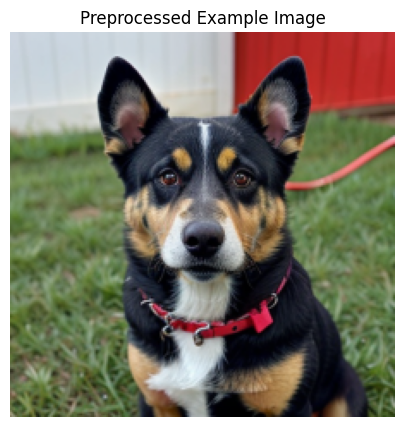

In [ ]:
if image_files:
    # Take the first image file for demonstration
    example_image_path = image_files[0]
    print(f"Preprocessing example image: {example_image_path}")

    # Preprocess the image using the new function
    preprocessed_example_image = preprocess_image(example_image_path)

    if preprocessed_example_image is not None:
        print(f"Preprocessed image shape: {preprocessed_example_image.shape}")
        print(f"Preprocessed image min value: {preprocessed_example_image.min()}")
        print(f"Preprocessed image max value: {preprocessed_example_image.max()}")

        # Display the preprocessed image
        plt.figure(figsize=(5, 5))
        plt.imshow(preprocessed_example_image) # imshow expects float in [0,1] for RGB
        plt.title('Preprocessed Example Image')
        plt.axis('off')
        plt.show()
    else:
        print("Failed to preprocess the example image.")
else:
    print("No image files found to demonstrate the function.")